In [5]:
from google.colab import files
uploaded = files.upload()

import pandas as pd
import numpy as np
from datetime import datetime
import matplotlib.pyplot as plt
import seaborn as sns
from lifetimes import BetaGeoFitter, GammaGammaFitter
from lifetimes.fitters import ConvergenceError


Saving RFM1.csv to RFM1.csv
Saving Online_retail.csv to Online_retail.csv


In [2]:
!pip install lifetimes

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 584.2/584.2 kB 10.3 MB/s eta 0:00:00


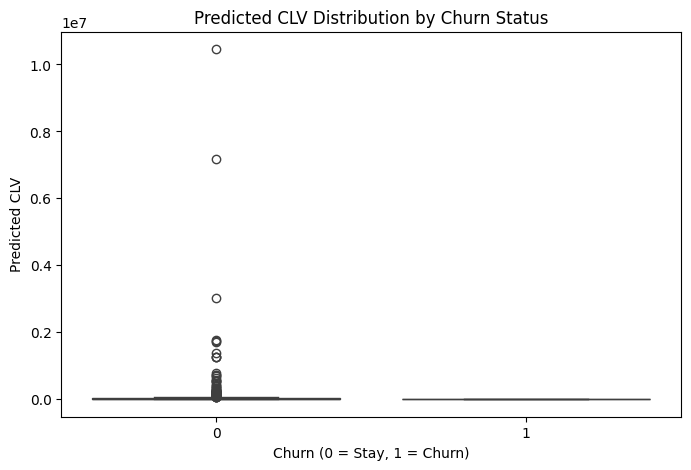

    CustomerID  predicted_purchases  predicted_avg_value  predicted_clv
1      12347.0             2.460683          4475.295896   10637.121664
5      12352.0             0.005445          2589.902967      13.620616
11     12358.0             3.113077          1342.711422    4037.762279
12     12359.0             2.640397          6812.516801   17375.215987
15     12362.0             7.373007          5364.875842   38208.290075


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from lifetimes import BetaGeoFitter, GammaGammaFitter

# Load data
rfm_df = pd.read_csv('Online_retail.csv', encoding='ISO-8859-1')
rfm_df['InvoiceDate'] = pd.to_datetime(rfm_df['InvoiceDate'], errors='coerce')

# Filter valid rows
rfm_df = rfm_df[
    (rfm_df['CustomerID'].notnull()) &
    (rfm_df['Quantity'] > 0) &
    (rfm_df['UnitPrice'] > 0)
]

# Total Price
rfm_df['TotalPrice'] = rfm_df['Quantity'] * rfm_df['UnitPrice']

# Reference analysis date
analysis_date = rfm_df['InvoiceDate'].max()

# RFM Aggregation
summary = rfm_df.groupby('CustomerID').agg({
    'InvoiceDate': [lambda x: (x.max() - x.min()).days,  # Recency
                    lambda x: (analysis_date - x.min()).days],  # T
    'InvoiceNo': 'nunique',  # Frequency
    'TotalPrice': 'sum'  # Monetary
})

summary.columns = ['recency', 'T', 'frequency', 'monetary_value']
summary = summary.reset_index()

# Filter: remove 0 values required by models
summary = summary[
    (summary['frequency'] > 1) &
    (summary['recency'] > 0) &
    (summary['T'] > 0) &
    (summary['monetary_value'] > 0)
]

# Fit BG/NBD Model
bgf = BetaGeoFitter(penalizer_coef=10.0)
bgf.fit(summary['frequency'], summary['recency'], summary['T'])

# Predict expected purchases in next 6 months (180 days)
summary['predicted_purchases'] = bgf.conditional_expected_number_of_purchases_up_to_time(
    180, summary['frequency'], summary['recency'], summary['T']
)

# Fit Gamma-Gamma Model
ggf = GammaGammaFitter(penalizer_coef=0.01)
ggf.fit(summary['frequency'], summary['monetary_value'])

# Predict average transaction value
summary['predicted_avg_value'] = ggf.conditional_expected_average_profit(
    summary['frequency'], summary['monetary_value']
)

# Predict CLV
summary['predicted_clv'] = ggf.customer_lifetime_value(
    bgf,
    summary['frequency'],
    summary['recency'],
    summary['T'],
    summary['monetary_value'],
    time=6,  # CLV for next 6 months
    freq='D',
    discount_rate=0.01
)

# Churn Analysis
rfm_clv_churn = summary.dropna(subset=['predicted_clv'])
if not rfm_clv_churn.empty:
    clv_median = rfm_clv_churn['predicted_clv'].median()
    rfm_clv_churn['Churn'] = (rfm_clv_churn['predicted_clv'] < clv_median).astype(int)

    # Plot
    plt.figure(figsize=(8, 5))
    sns.boxplot(x='Churn', y='predicted_clv', data=rfm_clv_churn)
    plt.title('Predicted CLV Distribution by Churn Status')
    plt.xlabel('Churn (0 = Stay, 1 = Churn)')
    plt.ylabel('Predicted CLV')
    plt.show()
else:
    print("No valid CLV predictions for churn analysis.")

# Output
print(summary[['CustomerID', 'predicted_purchases', 'predicted_avg_value', 'predicted_clv']].head())


In [7]:
print("CLV median:", clv_median)
print(rfm_clv_churn['Churn'].value_counts())


CLV median: 5321.624470107603
Churn
0    732
1    731
Name: count, dtype: int64


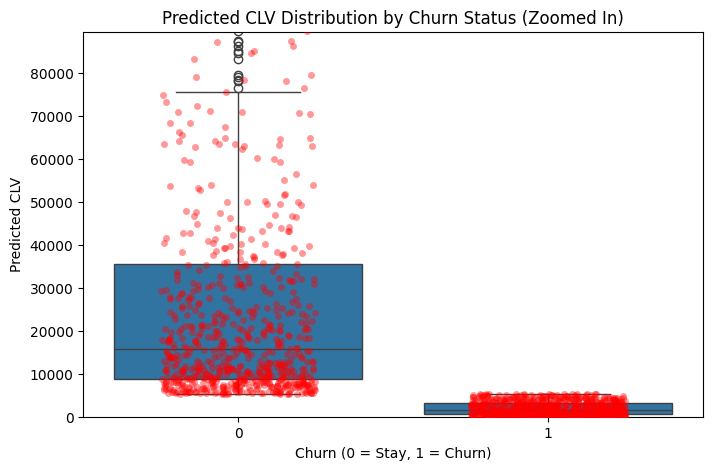

In [8]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='Churn', y='predicted_clv', data=rfm_clv_churn)
sns.stripplot(x='Churn', y='predicted_clv', data=rfm_clv_churn, color='red', alpha=0.4, jitter=0.25)

# Limit y-axis to better visualize lower range
plt.ylim(0, rfm_clv_churn['predicted_clv'].quantile(0.95))  # show up to 95th percentile

plt.title('Predicted CLV Distribution by Churn Status (Zoomed In)')
plt.xlabel('Churn (0 = Stay, 1 = Churn)')
plt.ylabel('Predicted CLV')
plt.show()


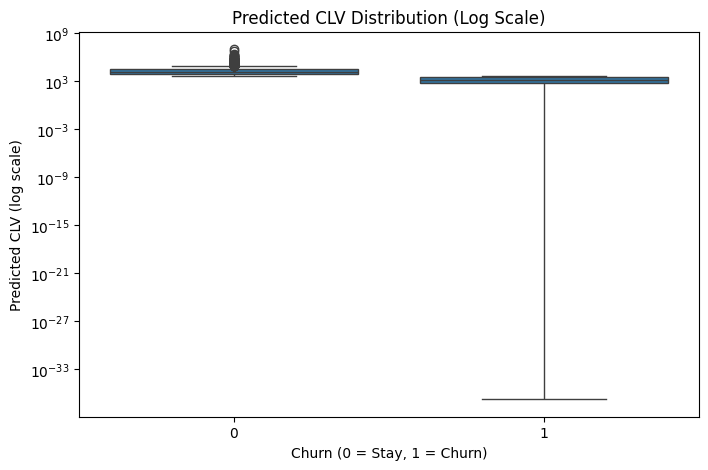

In [9]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='Churn', y='predicted_clv', data=rfm_clv_churn)
plt.yscale('log')
plt.title('Predicted CLV Distribution (Log Scale)')
plt.xlabel('Churn (0 = Stay, 1 = Churn)')
plt.ylabel('Predicted CLV (log scale)')
plt.show()
